In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random

Check for GPU

In [2]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))
#CPU training is slower than GPU because it has fewer cores and performs operations sequentially whereas GPU cores are build for parallel processing.

GPU Available: []


In [3]:
tf.random.set_seed(42)# Controls randomness in TensorFlow
np.random.seed(42)# Controls randomness in NumPy operations
random.seed(42)# Controls randomness in Python's built-in functions

In [4]:
from tensorflow.keras.datasets import mnist, cifar10

(x_train_m, y_train_m), (x_test_m, y_test_m) = mnist.load_data()
(x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()

print(x_train_m.shape, x_train_c.shape)
print(x_train_m.dtype, np.min(x_train_m), np.max(x_train_m))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28) (50000, 32, 32, 3)
uint8 0 255


In [5]:
import collections

mnist_class_counts = collections.Counter(y_train_m)

print("MNIST Training Set - Samples per Class:")
for class_label, count in sorted(mnist_class_counts.items()):
    print(f"Class {class_label}: {count} samples")

MNIST Training Set - Samples per Class:
Class 0: 5923 samples
Class 1: 6742 samples
Class 2: 5958 samples
Class 3: 6131 samples
Class 4: 5842 samples
Class 5: 5421 samples
Class 6: 5918 samples
Class 7: 6265 samples
Class 8: 5851 samples
Class 9: 5949 samples


The MNIST dataset is generally considered balanced, as each digit class has a similar number of samples.

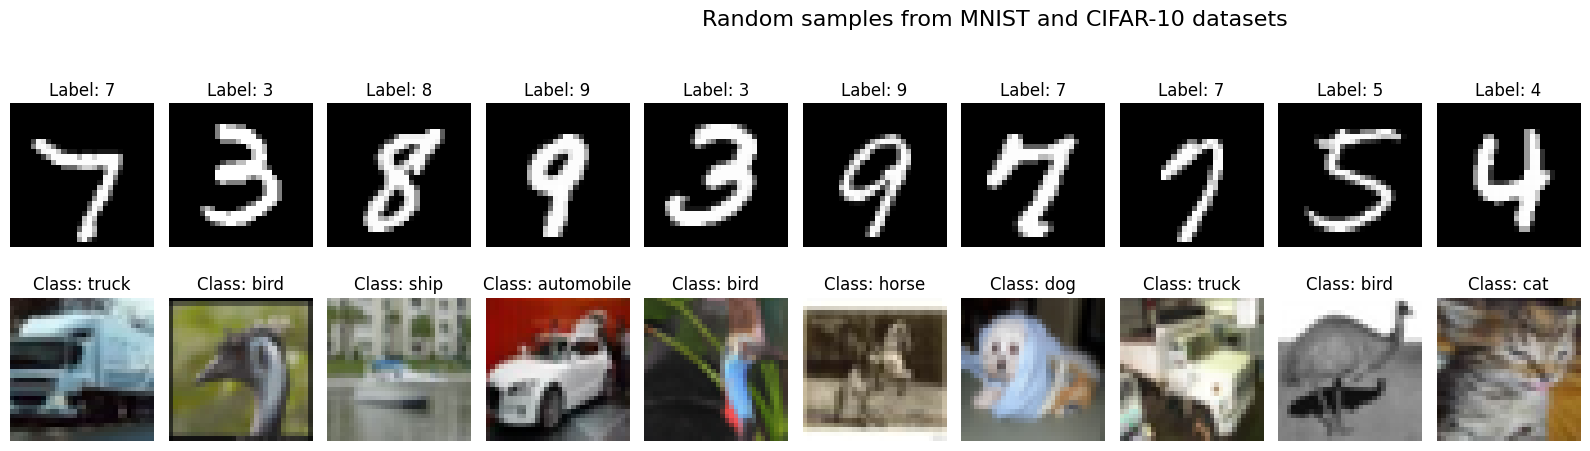

In [6]:
cifar10_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Random samples from MNIST and CIFAR-10 datasets', fontsize=16)

mnist_indices = np.random.choice(len(x_train_m), 10, replace=False)
for i, idx in enumerate(mnist_indices):
    axes[0, i].imshow(x_train_m[idx], cmap='gray')
    axes[0, i].set_title(f"Label: {y_train_m[idx]}")
    axes[0, i].axis('off')

cifar_indices = np.random.choice(len(x_train_c), 10, replace=False)
for i, idx in enumerate(cifar_indices):
    axes[1, i].imshow(x_train_c[idx])
    class_label = y_train_c[idx][0] if isinstance(y_train_c[idx], np.ndarray) else y_train_c[idx]
    axes[1, i].set_title(f"Class: {cifar10_class_names[class_label]}")
    axes[1, i].axis('off')

plt.tight_layout(rect=[0, 0.03, 0.80, 0.95])
plt.savefig('dataset_samples.png')
plt.show()

In [7]:
from tensorflow.keras.utils import to_categorical

def preprocess(x, y, is_mnist=True):
    x = x.astype('float32') / 255.0
    print("\n--- After Normalization ---")
    print("x_normalized_m shape:", x.shape)
    print("x_normalized_m sample (first image, top-left pixel):", x[0, 0, 0])
    print("x_normalized_m dtype:", x.dtype)

    if is_mnist:
        x = x.reshape(-1, 28, 28, 1)
        print("\n--- After Reshaping ---")
        print("x_reshaped_m shape:", x.shape)
        print("x_reshaped_m sample (first image, top-left pixel):", x[0, 0, 0])
        print("x_reshaped_m dtype:", x.dtype)

    y = to_categorical(y, 10)
    print("\n--- After One-Hot Encoding ---")
    print("y_onehot_m shape:", y.shape)
    print("y_onehot_m sample (first label):", y[0])
    print("y_onehot_m dtype:", y.dtype)
    return x, y

x_train_m, y_train_m = preprocess(x_train_m, y_train_m)
x_train_c, y_train_c = preprocess(x_train_c, y_train_c, False)


--- After Normalization ---
x_normalized_m shape: (60000, 28, 28)
x_normalized_m sample (first image, top-left pixel): 0.0
x_normalized_m dtype: float32

--- After Reshaping ---
x_reshaped_m shape: (60000, 28, 28, 1)
x_reshaped_m sample (first image, top-left pixel): [0.]
x_reshaped_m dtype: float32

--- After One-Hot Encoding ---
y_onehot_m shape: (60000, 10)
y_onehot_m sample (first label): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
y_onehot_m dtype: float64

--- After Normalization ---
x_normalized_m shape: (50000, 32, 32, 3)
x_normalized_m sample (first image, top-left pixel): [0.23137255 0.24313726 0.24705882]
x_normalized_m dtype: float32

--- After One-Hot Encoding ---
y_onehot_m shape: (50000, 10)
y_onehot_m sample (first label): [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
y_onehot_m dtype: float64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


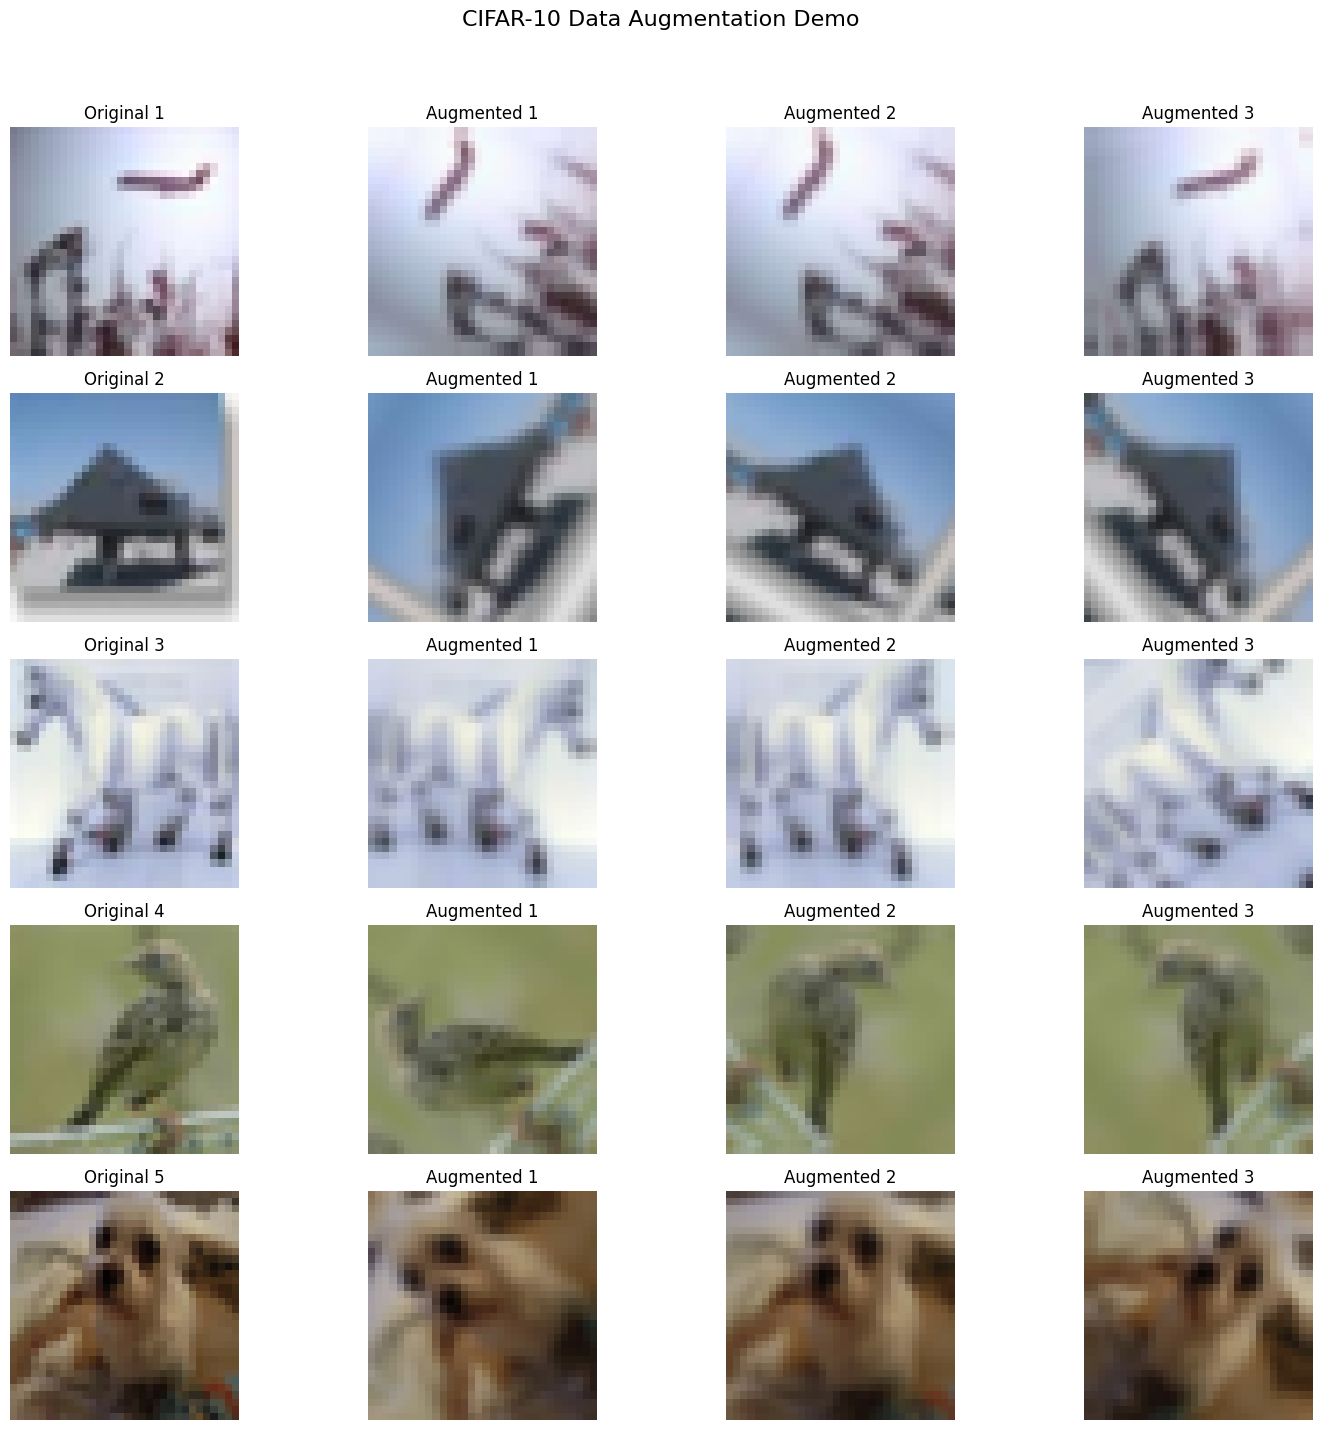

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", input_shape=(32, 32, 3)),
    tf.keras.layers.RandomRotation(factor=0.17453), # ~ +/- 10 degrees (0.17453 radians)
    tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1)
])

num_images = 5
random_indices = np.random.choice(len(x_train_c), num_images, replace=False)

fig, axes = plt.subplots(num_images, 4, figsize=(15, 15))
fig.suptitle('CIFAR-10 Data Augmentation Demo', fontsize=16)

for i, original_idx in enumerate(random_indices):
    original_image = x_train_c[original_idx]
    axes[i, 0].imshow(original_image)
    axes[i, 0].set_title(f'Original {i+1}')
    axes[i, 0].axis('off')

    for j in range(1, 4):
        augmented_image = data_augmentation(tf.expand_dims(original_image, 0))
        axes[i, j].imshow(augmented_image[0])
        axes[i, j].set_title(f'Augmented {j}')
        axes[i, j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('augmentation_demo.png')
plt.show()

Data Augmentation is applied only on Training data to improve generalisation and avoid overfitting. Whereas, it is not applicable on test or validation data beacause the datasets must represent real, unseen data for fair and unbiased evaluation.



Questions:

Q1.What does the channel dimension represent in a tensor of shape (N, H, W, C)?
Explain with reference to both a greyscale image and an RGB image.

ANS. A tensor of shape (N, H, W, C) represents:

      N → number of images (batch size)
      H → height of image
      W → width of image
      C (channel dimension) → number of feature channels per pixel
  The channel dimension (C) is 1 for grayscale images (intensity) and 3 for RGB images (red, green, blue color channels).


Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images, what data loading strategies would you use to avoid running out of memory? Name at least two techniques and explain how each one helps.

ANS. Training on 1024×1024 images requires much more memory than 32×32, so efficient data handling is necessary.

🔹 Technique 1: Mini-batch Loading

    Load only a small batch of images at a time
    Reduces RAM/GPU memory usage significantly

🔹 Technique 2: Image Resizing / Downsampling

    Resize images to a smaller size while keeping the essential features.
    Faster computation and lower memory consumption

Q3. Suppose a student applies normalisation to the test set using the mean and standard deviation computed from the test set itself. What is wrong with this approach?

ANS. Normalising the test set using its own statistics causes data leakage and leads to biased evaluation; instead, the test set must be normalised using the mean and standard deviation computed from the training data.